# Demo 04: adversarial robustness of an encoding axis

How far can a bounded pixel perturbation move a model's predicted response? `scripts/adversarial/adv_robustness_attack.py`
runs projected gradient descent (PGD) on the differentiable readout chain in both directions inside an
$L_\infty$ (and $L_2$) ball of radius $\epsilon$ and reports the **normalized swing**

$$\text{swing}(\epsilon) = \frac{\hat y_{\text{up}} - \hat y_{\text{down}}}{q_{99} - q_{01}},$$

the bidirectional reach of the attack in units of the site's natural response range. Robust models yield small
swings per unit $\epsilon$. This notebook imports that script and reuses its `pgd`, `make_normalizer` and
`grad_sensitivity` functions unchanged.

**Scale.** The paper: 100 held-out NSD images (never used for fitting or synthesis), $\epsilon \in \{0.5, 1, 2, 4, 8, 16, 32, 64\}/255$,
50 PGD steps of size $2.5\epsilon/\text{steps}$ plus one random restart, both norms, all 250 readouts
(`cluster_outputs/fig5_ext_heldout/adv_robustness_<model>_<monkey>.csv`). `FULL_SCALE = False`: 3 held-out
calibration images (the 100 NSD probe images are not part of the release, so the three images are drawn from the
held-out *test* split of the calibration set), $\epsilon \in \{1, 2, 4, 8, 16\}/255$, 10 steps, no restart,
$L_\infty$ only, site (Monkey R, 9) under ResNet-50 and robust ResNet-50.

In [1]:
%matplotlib inline
import os
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')   # multithreaded BLAS + torch can crash the Jupyter kernel on macOS
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import os, sys, time
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]   # kernel may start in the repo root or in notebooks/demos
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / 'notebooks' / 'demos'))
from pnc import paths
HINT = 'python data/download_data.py --tier source   (README section 2)'
# fail early, with the download command, if a data tier this demo reads is missing
paths.require(paths.source_data() / 'image_pca_projections', HINT)
paths.require(paths.source_data() / 'encoding_model_outputs', HINT)
paths.require(paths.source_data() / 'model_backbones' / 'imagenet_linf_8_pure.pt', HINT)
paths.require(paths.cluster_outputs() / 'fig5_ext_heldout', HINT)
paths.require(paths.source_data() / 'stimuli_encoding', HINT)
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pnc.utils import apply_figure_style
apply_figure_style(); plt.rcParams['figure.dpi'] = 90
torch.set_num_threads(max(1, os.cpu_count() // 2)); torch.manual_seed(0); np.random.seed(0)
print('source_data       =', paths.source_data())
print('preprocessed_data =', paths.preprocessed_data())

source_data       = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/source_data
preprocessed_data = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/preproc_build


In [2]:
FULL_SCALE = False
MONKEY, UNIT = 'red', 9
MODELS = ['resnet50', 'resnet50_robust']
if FULL_SCALE:
    EPS_255, STEPS, RESTARTS, N_IMAGES = [0.5, 1, 2, 4, 8, 16, 32, 64], 50, 1, 100
else:
    EPS_255, STEPS, RESTARTS, N_IMAGES = [1, 2, 4, 8, 16], 10, 0, 3
NORM = 'linf'
print(f'eps/255 = {EPS_255}, steps = {STEPS}, restarts = {RESTARTS}, images = {N_IMAGES}, norm = {NORM}')

eps/255 = [1, 2, 4, 8, 16], steps = 10, restarts = 0, images = 3, norm = linf


## 1. Import the attack script

`adv_robustness_attack.py` reads its data root from `PNC_SOURCE_DATA` at import, so the environment variable is
pinned to `paths.source_data()` first. Its heavy model imports are lazy; the PGD and metric helpers import cleanly.

In [3]:
os.environ['PNC_SOURCE_DATA'] = str(paths.source_data())
sys.path.insert(0, str(REPO / 'scripts' / 'adversarial'))
import adv_robustness_attack as ara
import inspect
print(inspect.getsource(ara.pgd))                        # the attack loop exactly as the production script runs it
print('DEFAULT_EPS_255 =', ara.DEFAULT_EPS_255, '| IMG_PX =', ara.IMG_PX, '| N_PIX =', ara.N_PIX)

def pgd(objective, x0, eps, norm, sign, steps, alpha, restarts):
    """Maximize sign*objective within an eps-ball of x0.  Returns best predictions (B,)."""
    best = torch.full((x0.size(0),), -np.inf, device=x0.device)      # best sign*pred
    best_pred = objective(x0).detach()                                # start from clean
    best = torch.maximum(best, sign * best_pred)
    for t in range(restarts + 1):           # trajectory 0 = clean start, then random restarts
        x = x0.clone() if t == 0 else _rand_start(x0, eps, norm).detach()
        for _s in range(steps):
            x.requires_grad_(True)
            pred = objective(x)
            loss = (sign * pred).sum()
            grad, = torch.autograd.grad(loss, x)
            with torch.no_grad():
                if norm == "linf":
                    x = x + alpha * grad.sign()
                else:
                    flat = grad.view(grad.size(0), -1)
                    g = (flat / flat.norm(dim=1, keepdim=True).clamp_

## 2. The cached full-scale results

Inspect the csv before overlaying it: one row per (readout, image, norm, eps) with the clean prediction, the two
attacked predictions and the first-order gradient norms; `range_q99q01` is the normalizer of the swing.

In [4]:
csv = {m: pd.read_csv(paths.require(paths.cluster_outputs() / 'fig5_ext_heldout' / f'adv_robustness_{m}_{MONKEY}.csv', HINT)) for m in MODELS}
df = csv['resnet50']
print('columns:', df.columns.tolist())
print(df.shape, '| norms', df.norm.unique().tolist(), '| eps_255', sorted(df.eps_255.unique().tolist()),
      '| channels', sorted(df.channel.unique().tolist()), '| images', df.img_name.nunique())
df.query('channel == @UNIT and norm == @NORM').head(4)

columns: ['model', 'monkey', 'monkey_dir', 'channel', 'layer', 'range_q99q01', 'range_q95q05', 'range_minmax', 'std_resp', 'd2_test', 'reliability', 'ncsnr', 'img_idx', 'img_name', 'norm', 'eps_255', 'clean_pred', 'adv_up', 'adv_dn', 'grad_l2', 'grad_l1']
(8000, 21) | norms ['linf', 'l2'] | eps_255 [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0] | channels [0, 2, 9, 15, 19] | images 100


,model,monkey,monkey_dir,channel,layer,range_q99q01,range_q95q05,range_minmax,std_resp,d2_test,...,ncsnr,img_idx,img_name,norm,eps_255,clean_pred,adv_up,adv_dn,grad_l2,grad_l1
3200,resnet50,red,red_20250428-20250430,9,.layer4.Bottleneck0,4.236464,2.167204,5.349195,0.809142,0.746824,...,1.230419,0,shared0015_nsd03683.png,linf,0.5,-0.198937,1.295451,-1.289254,4.068583,903.494873
3201,resnet50,red,red_20250428-20250430,9,.layer4.Bottleneck0,4.236464,2.167204,5.349195,0.809142,0.746824,...,1.230419,1,shared0034_nsd04691.png,linf,0.5,0.042643,1.088909,-0.844282,2.184956,549.498413
3202,resnet50,red,red_20250428-20250430,9,.layer4.Bottleneck0,4.236464,2.167204,5.349195,0.809142,0.746824,...,1.230419,2,shared0037_nsd04836.png,linf,0.5,-0.317901,0.525643,-0.986003,2.062050,432.519958
3203,resnet50,red,red_20250428-20250430,9,.layer4.Bottleneck0,4.236464,2.167204,5.349195,0.809142,0.746824,...,1.230419,3,shared0046_nsd05339.png,linf,0.5,-0.127415,1.174740,-1.253249,7.233984,1588.436157


## 3. Images and objectives

Three NSD images from the held-out test split, on the common 224-px [0,1] canvas the attack script uses; the
objective per model is the readout chain of demo 02 (`_demo_utils.EncodingObjective`), with the script's own
normalizer extracted from the model's preprocessing pipeline.

In [5]:
import _demo_utils as U
from pnc.utils import MODEL_SHORT_NAMES, get_model_color
split = pd.read_csv(paths.source_data() / 'stimuli_encoding' / 'encoding_stimuli_split_seed0.csv')
heldout = split.query('is_nsd and not is_train').stimulus_name.values   # never used for fitting; stands in for the unreleased probe set
rng = np.random.RandomState(0)
img_names = list(rng.choice(heldout, N_IMAGES, replace=False))
x0, names = ara.load_canvas(img_names, 'cpu')            # (N,3,224,224) in [0,1]
print('images:', names, tuple(x0.shape))

objs = {}
for m in MODELS:
    backbone, transform = U.load_backbone(m)
    normalizer = ara.make_normalizer(transform, 'cpu')   # the script's differentiable Normalize
    o = U.EncodingObjective(m, MONKEY, UNIT, backbone=backbone)
    objs[m] = (lambda x, o=o, nz=normalizer: o.from_normalized(nz(x)))   # pgd perturbs the [0,1] canvas; normalize inside the objective
    objs[m].range = o.stats['q99_resp'] - o.stats['q01_resp']   # natural response range: the swing normalizer
    print(f'{m:16s} layer {o.layer:22s} range_q99q01 = {objs[m].range:.3f}   (csv: {csv[m].query("channel == @UNIT").range_q99q01.iloc[0]:.3f})')

images: ['shared0078_nsd07481.png', 'shared0416_nsd30936.png', 'shared0656_nsd47657.png'] (3, 3, 224, 224)


/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


resnet50         layer .layer4.Bottleneck0    range_q99q01 = 4.236   (csv: 4.236)


/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


resnet50_robust  layer .layer4.Bottleneck2    range_q99q01 = 4.236   (csv: 4.236)


## 4. PGD up / down over the epsilon ladder

For every $\epsilon$: `pgd(objective, x0, eps, norm, +1, ...)` maximizes the prediction, `sign = -1` minimizes it
(step size $2.5\epsilon/\text{steps}$ with sign-gradient steps and projection, as in the script).

In [6]:
rows = []
t0 = time.time()
for m in MODELS:
    obj = objs[m]
    clean = ara.clean_predict(obj, x0).numpy()
    g2, g1 = ara.grad_sensitivity(obj, x0)               # first-order sensitivity: L2 / L1 norm of the clean input gradient
    for e255 in EPS_255:
        eps = e255 / 255.0
        alpha = 2.5 * eps / STEPS
        up = ara.pgd(obj, x0, eps, NORM, +1.0, STEPS, alpha, RESTARTS).numpy()
        dn = ara.pgd(obj, x0, eps, NORM, -1.0, STEPS, alpha, RESTARTS).numpy()
        for i, nm in enumerate(names):
            rows.append(dict(model=m, img_name=nm, eps_255=e255, clean_pred=clean[i], adv_up=up[i], adv_dn=dn[i],
                             grad_l2=float(g2[i]), swing=(up[i] - dn[i]) / obj.range))
    print(f'{m}: done ({time.time() - t0:.0f} s)')
ours = pd.DataFrame(rows)
ours.round(3)

resnet50: done (59 s)


resnet50_robust: done (121 s)


,model,img_name,eps_255,clean_pred,adv_up,adv_dn,grad_l2,swing
0,resnet50,shared0078_nsd07481.png,1,-0.045,1.904,-1.715,2.619,0.854
1,resnet50,shared0416_nsd30936.png,1,0.664,3.097,-1.207,5.304,1.016
2,resnet50,shared0656_nsd47657.png,1,-0.544,1.054,-1.915,2.842,0.701
3,resnet50,shared0078_nsd07481.png,2,-0.045,3.175,-2.510,2.619,1.342
4,resnet50,shared0416_nsd30936.png,2,0.664,4.437,-1.964,5.304,1.511
5,resnet50,shared0656_nsd47657.png,2,-0.544,1.983,-2.454,2.842,1.047
6,resnet50,shared0078_nsd07481.png,4,-0.045,4.497,-3.181,2.619,1.812
7,resnet50,shared0416_nsd30936.png,4,0.664,5.734,-2.653,5.304,1.980
8,resnet50,shared0656_nsd47657.png,4,-0.544,3.257,-3.060,2.842,1.491
9,resnet50,shared0078_nsd07481.png,8,-0.045,5.438,-3.667,2.619,2.149


## 5. Swing vs epsilon, this run against the cached full-scale sweep

Lines: mean normalized swing of this run over the 3 images (markers = individual images). Bands: mean +/- s.d.
over the 100 held-out images of the cached csv for the same site and models (`(adv_up - adv_dn) / range_q99q01`,
the definition used by `figures/main/fig5_adv.py`).

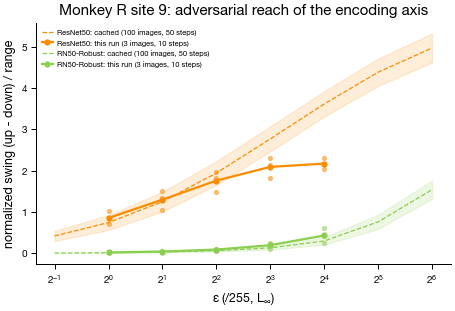

eps_255             1      2      4      8      16
model                                             
resnet50         0.857  1.300  1.761  2.093  2.173
resnet50_robust  0.023  0.046  0.093  0.199  0.433


In [7]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
for m in MODELS:
    c = get_model_color(m)
    ref = csv[m].query('channel == @UNIT and norm == @NORM').copy()
    ref['swing'] = (ref.adv_up - ref.adv_dn) / ref.range_q99q01
    g = ref.groupby('eps_255').swing.agg(['mean', 'std']).reset_index()
    ax.fill_between(g.eps_255, g['mean'] - g['std'], g['mean'] + g['std'], color=c, alpha=0.15)
    ax.plot(g.eps_255, g['mean'], '--', color=c, lw=1, label=f'{MODEL_SHORT_NAMES[m]}: cached (100 images, 50 steps)')
    o = ours.query('model == @m')
    ax.plot(o.groupby('eps_255').swing.mean().index, o.groupby('eps_255').swing.mean().values, '-o', color=c, lw=1.8,
            label=f'{MODEL_SHORT_NAMES[m]}: this run ({N_IMAGES} images, {STEPS} steps)')
    ax.scatter(o.eps_255, o.swing, s=10, color=c, alpha=0.5)
ax.set_xscale('log', base=2); ax.set(xlabel=r'$\epsilon$ (/255, $L_\infty$)', ylabel='normalized swing (up - down) / range',
                                     title=f'Monkey R site {UNIT}: adversarial reach of the encoding axis')
ax.legend(fontsize=6); plt.tight_layout(); plt.show()
print(ours.groupby(['model', 'eps_255']).swing.mean().unstack().round(3))